In [2]:
"""
BA820 - M2
Author: bhavya
Date: February 2026

"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ks_2samp, wasserstein_distance, spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.cluster import AgglomerativeClustering
import warnings
warnings.filterwarnings('ignore')

# Configuration
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [4]:
# ============================================================================
# SECTION 0: SETUP AND DATA LOADING
# ============================================================================

print("="*80)
print("M2 Q4: ULTIMATE COUPLE TYPE AGE-GAP ANALYSIS")
print("="*80)

# Create output directories
OUT_DIR = "m2_q4_outputs"
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(f"{OUT_DIR}/figures", exist_ok=True)
os.makedirs(f"{OUT_DIR}/tables", exist_ok=True)

# Load data
DATA_PATH = "/content/age_gaps.csv"  # Adjust path if needed
df_raw = pd.read_csv(DATA_PATH)
print(f"\n[LOAD] Raw dataset: {df_raw.shape}")

# Basic preprocessing
df = df_raw.copy()
df["age_gap"] = pd.to_numeric(df["age_difference"], errors="coerce")
df = df.dropna(subset=["release_year", "age_gap"]).copy()
df["release_year"] = df["release_year"].astype(int)

# Temporal features
BASE_YEAR = int(df["release_year"].min())
df["years_since_start"] = df["release_year"] - BASE_YEAR
df["decade"] = (df["release_year"] // 10) * 10

# Couple type labeling (older partner first in cleaned dataset)
df["pairing_type"] = (
    df["character_1_gender"].astype(str).str.strip().str.lower()
    + "–" +
    df["character_2_gender"].astype(str).str.strip().str.lower()
)

# Focus on four main types
MAIN_TYPES = ["man–woman", "woman–man", "man–man", "woman–woman"]
df = df[df["pairing_type"].isin(MAIN_TYPES)].copy()

# Thresholds
PARITY_THRESHOLDS = [3, 5]  # Test sensitivity
LARGE_GAP = 20

df["is_large_gap"] = df["age_gap"] >= LARGE_GAP

print(f"[LOAD] Focused dataset: {df.shape}")
print(f"[LOAD] Couple types: {MAIN_TYPES}")

M2 Q4: ULTIMATE COUPLE TYPE AGE-GAP ANALYSIS

[LOAD] Raw dataset: (1155, 13)
[LOAD] Focused dataset: (1155, 18)
[LOAD] Couple types: ['man–woman', 'woman–man', 'man–man', 'woman–woman']


In [5]:
# ============================================================================
# SECTION 1: TEXT-BASED FEATURE ENGINEERING (Actor Recurrence Proxy)
# ============================================================================

print("\n" + "-"*80)
print("SECTION 1: TEXT-BASED FEATURE EXTRACTION")
print("-"*80)

# Actor name recurrence as star-power proxy
actor_counts = pd.concat([
    df["actor_1_name"],
    df["actor_2_name"]
]).value_counts()

df["older_actor_freq"] = df["actor_1_name"].map(actor_counts).fillna(0).astype(int)
df["younger_actor_freq"] = df["actor_2_name"].map(actor_counts).fillna(0).astype(int)
df["max_actor_freq"] = df[["older_actor_freq", "younger_actor_freq"]].max(axis=1)

print(f"Actor recurrence features created")
print(f"  Median older-actor frequency: {df['older_actor_freq'].median():.0f}")
print(f"  Max older-actor frequency: {df['older_actor_freq'].max():.0f}")

# Spearman correlation: age gap vs older actor frequency
rho_overall, p_overall = spearmanr(df["age_gap"], df["older_actor_freq"])
print(f"\nOverall Spearman correlation (age_gap ~ older_actor_freq):")
print(f"  ρ = {rho_overall:.3f}, p = {p_overall:.4f}")


--------------------------------------------------------------------------------
SECTION 1: TEXT-BASED FEATURE EXTRACTION
--------------------------------------------------------------------------------
Actor recurrence features created
  Median older-actor frequency: 4
  Max older-actor frequency: 27

Overall Spearman correlation (age_gap ~ older_actor_freq):
  ρ = 0.140, p = 0.0000


In [6]:
# ============================================================================
# SECTION 2: BASELINE DESCRIPTIVE STATISTICS WITH MULTIPLE PARITY THRESHOLDS
# ============================================================================

print("\n" + "-"*80)
print("SECTION 2: BASELINE STATISTICS (PARITY SENSITIVITY)")
print("-"*80)

baseline_tables = {}

for parity_cutoff in PARITY_THRESHOLDS:
    df[f"is_near_parity_{parity_cutoff}"] = df["age_gap"] <= parity_cutoff

    table = (
        df.groupby("pairing_type")
        .agg(
            n_pairs=("age_gap", "size"),
            mean_gap=("age_gap", "mean"),
            median_gap=("age_gap", "median"),
            std_gap=("age_gap", "std"),
            p25_gap=("age_gap", lambda x: x.quantile(0.25)),
            p75_gap=("age_gap", lambda x: x.quantile(0.75)),
            p_large_gap=("is_large_gap", "mean"),
            p_near_parity=(f"is_near_parity_{parity_cutoff}", "mean"),
            median_older_freq=("older_actor_freq", "median"),
            median_younger_freq=("younger_actor_freq", "median"),
        )
        .reindex(MAIN_TYPES)
    )

    baseline_tables[parity_cutoff] = table

    print(f"\n--- Parity threshold ≤{parity_cutoff} years ---")
    print(table.round(2))

    # Save to CSV
    table_export = table.copy()
    table_export["p_large_gap"] = (table_export["p_large_gap"] * 100).round(1)
    table_export["p_near_parity"] = (table_export["p_near_parity"] * 100).round(1)
    table_export.to_csv(f"{OUT_DIR}/tables/table_baseline_parity{parity_cutoff}.csv")


--------------------------------------------------------------------------------
SECTION 2: BASELINE STATISTICS (PARITY SENSITIVITY)
--------------------------------------------------------------------------------

--- Parity threshold ≤3 years ---
              n_pairs  mean_gap  median_gap  std_gap  p25_gap  p75_gap  \
pairing_type                                                             
man–woman         929     11.54        10.0     8.45     5.00     17.0   
woman–man         203      5.01         3.0     6.06     2.00      6.0   
man–man            12     15.42        13.5    12.54     7.75     20.0   
woman–woman        11     11.00         8.0     8.73     4.50     15.0   

              p_large_gap  p_near_parity  median_older_freq  \
pairing_type                                                  
man–woman            0.17           0.18                4.0   
woman–man            0.03           0.54                3.0   
man–man              0.25           0.17             

In [7]:
# ============================================================================
# SECTION 3: BOOTSTRAP CONFIDENCE INTERVALS (Uncertainty Quantification)
# ============================================================================

print("\n" + "-"*80)
print("SECTION 3: BOOTSTRAP UNCERTAINTY QUANTIFICATION")
print("-"*80)

def bootstrap_ci(x, stat_fn, n_boot=8000, seed=42, alpha=0.05):
    """Compute bootstrap confidence interval for a statistic"""
    rng = np.random.default_rng(seed)
    x = np.asarray(x)
    n = len(x)
    boots = np.empty(n_boot)
    for i in range(n_boot):
        boots[i] = stat_fn(rng.choice(x, size=n, replace=True))
    lo = np.quantile(boots, alpha/2)
    hi = np.quantile(boots, 1 - alpha/2)
    return float(lo), float(hi)

boot_rows = []
for ptype in MAIN_TYPES:
    xvals = df.loc[df["pairing_type"] == ptype, "age_gap"].to_numpy()
    n = len(xvals)

    # Median CI
    med = float(np.median(xvals))
    med_ci = bootstrap_ci(xvals, np.median, n_boot=8000, seed=1)

    # Parity rate CIs for both thresholds
    for parity_cutoff in PARITY_THRESHOLDS:
        pr = float(np.mean(xvals <= parity_cutoff))
        pr_ci = bootstrap_ci(
            xvals,
            lambda a: np.mean(a <= parity_cutoff),
            n_boot=8000,
            seed=parity_cutoff + 10
        )

        boot_rows.append({
            "pairing_type": ptype,
            "n": n,
            "median_gap": med,
            "median_ci_low": med_ci[0],
            "median_ci_high": med_ci[1],
            "median_ci_width": med_ci[1] - med_ci[0],
            "parity_cutoff": parity_cutoff,
            "near_parity_rate": pr,
            "near_parity_ci_low": pr_ci[0],
            "near_parity_ci_high": pr_ci[1],
            "near_parity_ci_width": pr_ci[1] - pr_ci[0],
        })

boot_df = pd.DataFrame(boot_rows)
boot_df.to_csv(f"{OUT_DIR}/tables/table_bootstrap_uncertainty.csv", index=False)

print("\nBootstrap 95% CIs (Parity ≤3 years):")
print(boot_df[boot_df["parity_cutoff"] == 3][
    ["pairing_type", "n", "median_gap", "median_ci_low", "median_ci_high",
     "near_parity_rate", "near_parity_ci_low", "near_parity_ci_high"]
].round(3))

print("\nKey observation: Note CI widths for same-gender types (n=11-12)")


--------------------------------------------------------------------------------
SECTION 3: BOOTSTRAP UNCERTAINTY QUANTIFICATION
--------------------------------------------------------------------------------

Bootstrap 95% CIs (Parity ≤3 years):
  pairing_type    n  median_gap  median_ci_low  median_ci_high  \
0    man–woman  929        10.0            9.0            10.0   
2    woman–man  203         3.0            3.0             4.0   
4      man–man   12        13.5            6.5            22.0   
6  woman–woman   11         8.0            4.0            16.0   

   near_parity_rate  near_parity_ci_low  near_parity_ci_high  
0             0.177               0.152                0.201  
2             0.537               0.468                0.606  
4             0.167               0.000                0.417  
6             0.182               0.000                0.455  

Key observation: Note CI widths for same-gender types (n=11-12)


In [8]:
# ============================================================================
# SECTION 4: PERMUTATION TESTS (Rigorous Hypothesis Testing)
# ============================================================================

print("\n" + "-"*80)
print("SECTION 4: PERMUTATION TESTS FOR MEDIAN DIFFERENCES")
print("-"*80)

def permutation_test(x, y, stat_fn, n_perm=10000, seed=42):
    """Two-sample permutation test"""
    rng = np.random.default_rng(seed)
    x = np.asarray(x)
    y = np.asarray(y)
    nx = len(x)
    pooled = np.concatenate([x, y]).copy()
    obs = stat_fn(x) - stat_fn(y)

    more_extreme = 0
    for _ in range(n_perm):
        rng.shuffle(pooled)
        perm_x = pooled[:nx]
        perm_y = pooled[nx:]
        diff = stat_fn(perm_x) - stat_fn(perm_y)
        if abs(diff) >= abs(obs):
            more_extreme += 1

    pval = (more_extreme + 1) / (n_perm + 1)
    return float(obs), float(pval)

# Key comparisons
perm_pairs = [
    ("man–woman", "woman–man"),
    ("man–woman", "man–man"),
    ("man–woman", "woman–woman"),
    ("woman–man", "woman–woman"),
]

perm_rows = []
for a, b in perm_pairs:
    xa = df.loc[df["pairing_type"] == a, "age_gap"].to_numpy()
    xb = df.loc[df["pairing_type"] == b, "age_gap"].to_numpy()
    obs, pval = permutation_test(xa, xb, np.median, n_perm=10000, seed=99)

    perm_rows.append({
        "comparison": f"{a} vs {b}",
        "nA": len(xa),
        "nB": len(xb),
        "median_diff": obs,
        "perm_pvalue": pval,
        "significant_05": "Yes" if pval < 0.05 else "No"
    })

perm_df = pd.DataFrame(perm_rows)
perm_df.to_csv(f"{OUT_DIR}/tables/table_permutation_tests.csv", index=False)

print("\nPermutation Test Results (10,000 permutations):")
print(perm_df.to_string(index=False))


--------------------------------------------------------------------------------
SECTION 4: PERMUTATION TESTS FOR MEDIAN DIFFERENCES
--------------------------------------------------------------------------------

Permutation Test Results (10,000 permutations):
              comparison  nA  nB  median_diff  perm_pvalue significant_05
  man–woman vs woman–man 929 203          7.0     0.000100            Yes
    man–woman vs man–man 929  12         -3.5     0.246375             No
man–woman vs woman–woman 929  11          2.0     0.641536             No
woman–man vs woman–woman 203  11         -5.0     0.013799            Yes


In [9]:
# ============================================================================
# SECTION 5: DISTRIBUTION DISTANCES (KS + Wasserstein)
# ============================================================================

print("\n" + "-"*80)
print("SECTION 5: DISTRIBUTION DISTANCE METRICS")
print("-"*80)

dist_rows = []
for a, b in perm_pairs:
    xa = df.loc[df["pairing_type"] == a, "age_gap"].to_numpy()
    xb = df.loc[df["pairing_type"] == b, "age_gap"].to_numpy()

    ks = ks_2samp(xa, xb)
    wass = wasserstein_distance(xa, xb)

    dist_rows.append({
        "comparison": f"{a} vs {b}",
        "wasserstein_distance": wass,
        "ks_statistic": ks.statistic,
        "ks_pvalue": ks.pvalue,
    })

dist_df = pd.DataFrame(dist_rows)
dist_df.to_csv(f"{OUT_DIR}/tables/table_distribution_distances.csv", index=False)

print("\nDistribution Distance Metrics:")
print(dist_df.round(4).to_string(index=False))



--------------------------------------------------------------------------------
SECTION 5: DISTRIBUTION DISTANCE METRICS
--------------------------------------------------------------------------------

Distribution Distance Metrics:
              comparison  wasserstein_distance  ks_statistic  ks_pvalue
  man–woman vs woman–man                6.5885        0.4453     0.0000
    man–woman vs man–man                4.2766        0.2460     0.4044
man–woman vs woman–woman                1.6189        0.1758     0.8333
woman–man vs woman–woman                6.2956        0.3708     0.0844


In [10]:
# ============================================================================
# SECTION 6: UNSUPERVISED METHOD 1 - GMM LATENT REGIME DISCOVERY
# ============================================================================

print("\n" + "-"*80)
print("SECTION 6: GMM - LATENT AGE-GAP REGIMES")
print("-"*80)

# Fit GMMs with different numbers of components
X_gmm = df[["age_gap"]].to_numpy().astype(float)

bics = []
models = {}
for k in range(1, 8):
    gmm_k = GaussianMixture(
        n_components=k,
        random_state=RANDOM_STATE,
        n_init=5,
        max_iter=300
    )
    gmm_k.fit(X_gmm)
    models[k] = gmm_k
    bics.append((k, gmm_k.bic(X_gmm)))

bic_df = pd.DataFrame(bics, columns=["n_components", "bic"])
best_k = int(bic_df.loc[bic_df["bic"].idxmin(), "n_components"])
gmm_best = models[best_k]

print(f"\nBIC-optimal number of components: k = {best_k}")
print(f"BIC values:\n{bic_df}")

bic_df.to_csv(f"{OUT_DIR}/tables/table_gmm_bic_selection.csv", index=False)

# Assign regimes (ordered by mean gap)
means = gmm_best.means_.flatten()
order = np.argsort(means)
map_old_to_new = {old: new for new, old in enumerate(order)}

df["gmm_component_raw"] = gmm_best.predict(X_gmm)
df["gap_regime"] = df["gmm_component_raw"].map(map_old_to_new)

# Regime summary
regime_summary = (
    df.groupby("gap_regime")
    .agg(
        n=("age_gap", "size"),
        mean_gap=("age_gap", "mean"),
        median_gap=("age_gap", "median"),
        std_gap=("age_gap", "std"),
        pct_large_gap=("is_large_gap", "mean"),
    )
    .reset_index()
)

regime_summary["pct_large_gap"] = (regime_summary["pct_large_gap"] * 100).round(1)
regime_summary.to_csv(f"{OUT_DIR}/tables/table_gap_regime_summary.csv", index=False)

print("\nGap Regime Characteristics:")
print(regime_summary.round(2))

# Regime composition by couple type
regime_by_type_pct = pd.crosstab(
    df["gap_regime"],
    df["pairing_type"],
    normalize="columns"
).reindex(columns=MAIN_TYPES)

regime_by_type_counts = pd.crosstab(
    df["gap_regime"],
    df["pairing_type"]
).reindex(columns=MAIN_TYPES)

regime_by_type_pct.to_csv(f"{OUT_DIR}/tables/table_regime_by_type_pct.csv")
regime_by_type_counts.to_csv(f"{OUT_DIR}/tables/table_regime_by_type_counts.csv")

print("\nRegime Composition (% within each couple type):")
print((regime_by_type_pct * 100).round(1))



--------------------------------------------------------------------------------
SECTION 6: GMM - LATENT AGE-GAP REGIMES
--------------------------------------------------------------------------------

BIC-optimal number of components: k = 4
BIC values:
   n_components          bic
0             1  8237.414868
1             2  7917.367764
2             3  7859.398068
3             4  7823.940292
4             5  7826.877861
5             6  7837.433139
6             7  7855.416941

Gap Regime Characteristics:
   gap_regime    n  mean_gap  median_gap  std_gap  pct_large_gap
0           0  414      2.71         3.0     1.54            0.0
1           1  401      9.13         9.0     2.21            0.0
2           2  279     18.91        18.0     3.55           40.1
3           3   61     32.48        30.0     5.86          100.0

Regime Composition (% within each couple type):
pairing_type  man–woman  woman–man  man–man  woman–woman
gap_regime                                          

In [11]:
# ============================================================================
# SECTION 7: UNSUPERVISED METHOD 2 - PCA PROJECTION
# ============================================================================

print("\n" + "-"*80)
print("SECTION 7: PCA - MULTIDIMENSIONAL STRUCTURE")
print("-"*80)

# Build rich feature matrix for each couple type
couple_features_list = []

for ptype in MAIN_TYPES:
    subset = df[df["pairing_type"] == ptype]

    # Distribution features
    mean_gap = subset["age_gap"].mean()
    median_gap = subset["age_gap"].median()
    std_gap = subset["age_gap"].std()
    p10 = subset["age_gap"].quantile(0.10)
    p90 = subset["age_gap"].quantile(0.90)
    iqr = subset["age_gap"].quantile(0.75) - subset["age_gap"].quantile(0.25)
    skew = subset["age_gap"].skew()

    # Behavioral features
    pct_parity = subset["is_near_parity_3"].mean()
    pct_large = subset["is_large_gap"].mean()

    # Text proxy features
    median_older_freq = subset["older_actor_freq"].median()
    median_younger_freq = subset["younger_actor_freq"].median()

    # Temporal
    early_median = subset[subset["release_year"] < 2000]["age_gap"].median()
    recent_median = subset[subset["release_year"] >= 2000]["age_gap"].median()
    temporal_shift = recent_median - early_median if not pd.isna(early_median) and not pd.isna(recent_median) else 0

    couple_features_list.append({
        "pairing_type": ptype,
        "n": len(subset),
        "mean_gap": mean_gap,
        "median_gap": median_gap,
        "std_gap": std_gap,
        "p10_gap": p10,
        "p90_gap": p90,
        "iqr_gap": iqr,
        "skewness": skew,
        "pct_near_parity": pct_parity,
        "pct_large_gap": pct_large,
        "median_older_freq": median_older_freq,
        "median_younger_freq": median_younger_freq,
        "temporal_shift": temporal_shift,
    })

df_couple_feat = pd.DataFrame(couple_features_list)
df_couple_feat.to_csv(f"{OUT_DIR}/tables/table_couple_multidim_features.csv", index=False)

print("\nMultidimensional Feature Matrix:")
print(df_couple_feat.round(2))

# PCA
feature_cols_pca = [
    "mean_gap", "median_gap", "std_gap", "p10_gap", "p90_gap",
    "iqr_gap", "skewness", "pct_near_parity", "pct_large_gap",
    "median_older_freq", "temporal_shift"
]

X_pca = df_couple_feat[feature_cols_pca].fillna(0).values
scaler_pca = StandardScaler()
X_pca_scaled = scaler_pca.fit_transform(X_pca)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_transformed = pca.fit_transform(X_pca_scaled)

df_couple_feat["pc1"] = X_pca_transformed[:, 0]
df_couple_feat["pc2"] = X_pca_transformed[:, 1]

explained_var = pca.explained_variance_ratio_
print(f"\nPCA Explained Variance:")
print(f"  PC1: {explained_var[0]:.3f} ({explained_var[0]*100:.1f}%)")
print(f"  PC2: {explained_var[1]:.3f} ({explained_var[1]*100:.1f}%)")
print(f"  Total: {explained_var.sum():.3f} ({explained_var.sum()*100:.1f}%)")

# Feature loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=feature_cols_pca
)
loadings.to_csv(f"{OUT_DIR}/tables/table_pca_loadings.csv")

print("\nTop PC1 Contributors:")
print(loadings["PC1"].abs().sort_values(ascending=False).head(5))


--------------------------------------------------------------------------------
SECTION 7: PCA - MULTIDIMENSIONAL STRUCTURE
--------------------------------------------------------------------------------

Multidimensional Feature Matrix:
  pairing_type    n  mean_gap  median_gap  std_gap  p10_gap  p90_gap  iqr_gap  \
0    man–woman  929     11.54        10.0     8.45      2.0     24.0    12.00   
1    woman–man  203      5.01         3.0     6.06      1.0     11.0     4.00   
2      man–man   12     15.42        13.5    12.54      1.3     28.7    12.25   
3  woman–woman   11     11.00         8.0     8.73      3.0     25.0    10.50   

   skewness  pct_near_parity  pct_large_gap  median_older_freq  \
0      1.03             0.18           0.17                4.0   
1      3.60             0.54           0.03                3.0   
2      0.91             0.17           0.25                4.5   
3      0.91             0.18           0.18                5.0   

   median_younger_freq

In [12]:
# ============================================================================
# SECTION 8: HIERARCHICAL CLUSTERING VALIDATION
# ============================================================================

print("\n" + "-"*80)
print("SECTION 8: HIERARCHICAL CLUSTERING (VALIDATION)")
print("-"*80)

# Quick hierarchical clustering on scaled features
hc = AgglomerativeClustering(n_clusters=2, linkage="ward")
df_couple_feat["hc_cluster"] = hc.fit_predict(X_pca_scaled)

print("\nHierarchical Cluster Assignments:")
for _, row in df_couple_feat.iterrows():
    print(f"  {row['pairing_type']:20s} → Cluster {row['hc_cluster']}")


--------------------------------------------------------------------------------
SECTION 8: HIERARCHICAL CLUSTERING (VALIDATION)
--------------------------------------------------------------------------------

Hierarchical Cluster Assignments:
  man–woman            → Cluster 0
  woman–man            → Cluster 1
  man–man              → Cluster 0
  woman–woman          → Cluster 0



--------------------------------------------------------------------------------
SECTION 9: GENERATING VISUALIZATIONS
--------------------------------------------------------------------------------


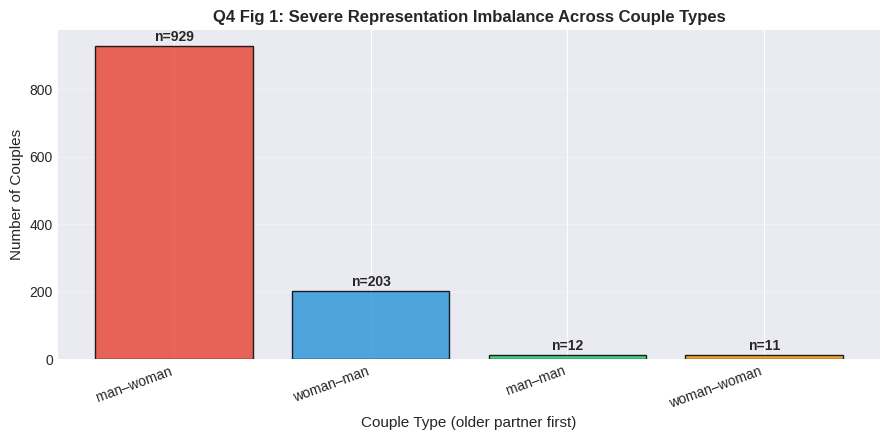

In [13]:
# ============================================================================
# SECTION 9: COMPREHENSIVE VISUALIZATIONS
# ============================================================================

print("\n" + "-"*80)
print("SECTION 9: GENERATING VISUALIZATIONS")
print("-"*80)

colors = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12"]

# --- FIG 1: Sample size imbalance ---
type_counts = df["pairing_type"].value_counts().reindex(MAIN_TYPES)
plt.figure(figsize=(9, 4.5))
bars = plt.bar(range(len(MAIN_TYPES)), type_counts.values, color=colors, alpha=0.85, edgecolor="black")
plt.xticks(range(len(MAIN_TYPES)), MAIN_TYPES, rotation=20, ha="right")
plt.ylabel("Number of Couples", fontsize=11)
plt.xlabel("Couple Type (older partner first)", fontsize=11)
plt.title("Q4 Fig 1: Severe Representation Imbalance Across Couple Types", fontsize=12, weight="bold")
plt.grid(axis="y", alpha=0.3)
for i, (bar, count) in enumerate(zip(bars, type_counts.values)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
             f"n={count}", ha="center", fontsize=10, weight="bold")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/figures/Q4_Fig1_Sample_Imbalance.png", dpi=300, bbox_inches="tight")
plt.show()

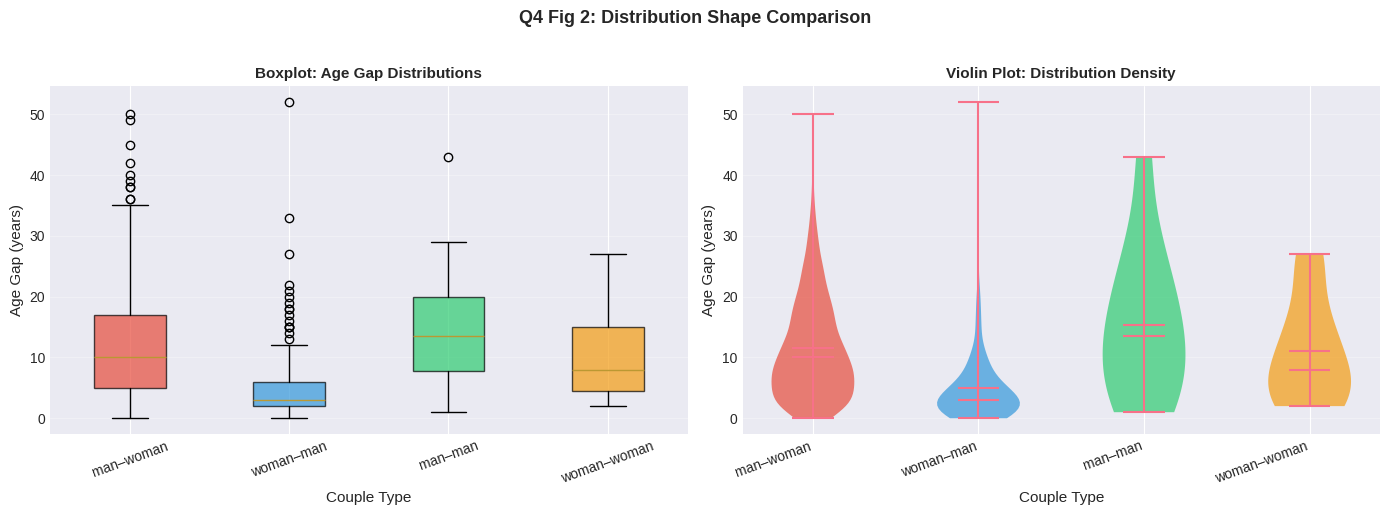

In [14]:
# --- FIG 2: Boxplot + Violin (Distribution Comparison) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

box_data = [df.loc[df["pairing_type"] == t, "age_gap"].values for t in MAIN_TYPES]
bp = axes[0].boxplot(box_data, labels=MAIN_TYPES, showfliers=True, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_ylabel("Age Gap (years)", fontsize=11)
axes[0].set_xlabel("Couple Type", fontsize=11)
axes[0].set_title("Boxplot: Age Gap Distributions", fontsize=11, weight="bold")
axes[0].tick_params(axis='x', rotation=20)
axes[0].grid(axis="y", alpha=0.3)

parts = axes[1].violinplot(box_data, positions=range(len(MAIN_TYPES)), showmeans=True, showmedians=True)
for pc, color in zip(parts['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)
axes[1].set_xticks(range(len(MAIN_TYPES)))
axes[1].set_xticklabels(MAIN_TYPES, rotation=20, ha="right")
axes[1].set_ylabel("Age Gap (years)", fontsize=11)
axes[1].set_xlabel("Couple Type", fontsize=11)
axes[1].set_title("Violin Plot: Distribution Density", fontsize=11, weight="bold")
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("Q4 Fig 2: Distribution Shape Comparison", fontsize=13, weight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/figures/Q4_Fig2_Distribution_Comparison.png", dpi=300, bbox_inches="tight")
plt.show()

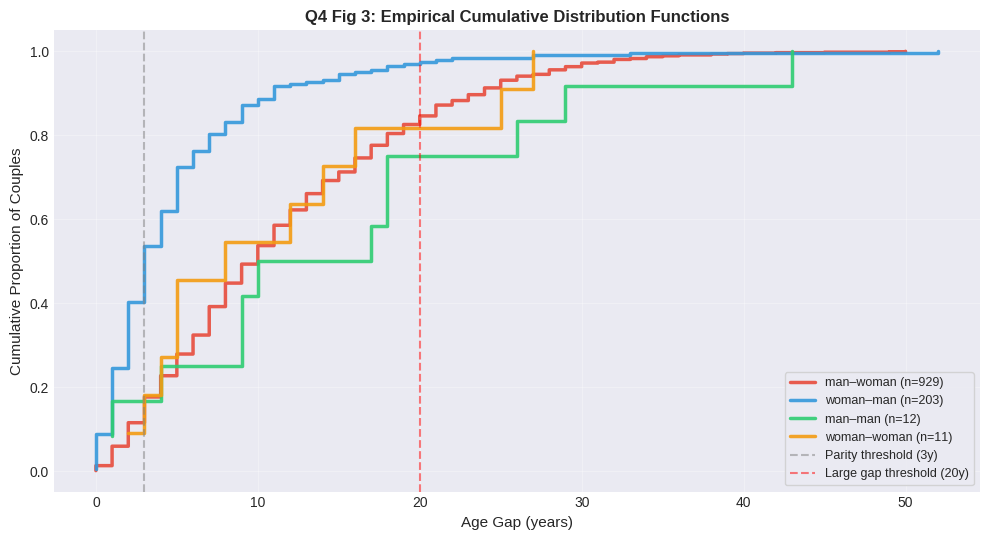

In [15]:
# --- FIG 3: ECDF (Cumulative Distribution) ---
plt.figure(figsize=(10, 5.5))
for t, color in zip(MAIN_TYPES, colors):
    x = np.sort(df.loc[df["pairing_type"] == t, "age_gap"].values)
    y = np.arange(1, len(x) + 1) / len(x)
    plt.step(x, y, where="post", label=f"{t} (n={len(x)})", alpha=0.9, linewidth=2.5, color=color)
plt.axvline(3, linestyle="--", color="gray", alpha=0.5, linewidth=1.5, label="Parity threshold (3y)")
plt.axvline(20, linestyle="--", color="red", alpha=0.5, linewidth=1.5, label="Large gap threshold (20y)")
plt.xlabel("Age Gap (years)", fontsize=11)
plt.ylabel("Cumulative Proportion of Couples", fontsize=11)
plt.title("Q4 Fig 3: Empirical Cumulative Distribution Functions", fontsize=12, weight="bold")
plt.legend(frameon=True, fontsize=9, loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/figures/Q4_Fig3_ECDF.png", dpi=300, bbox_inches="tight")
plt.show()

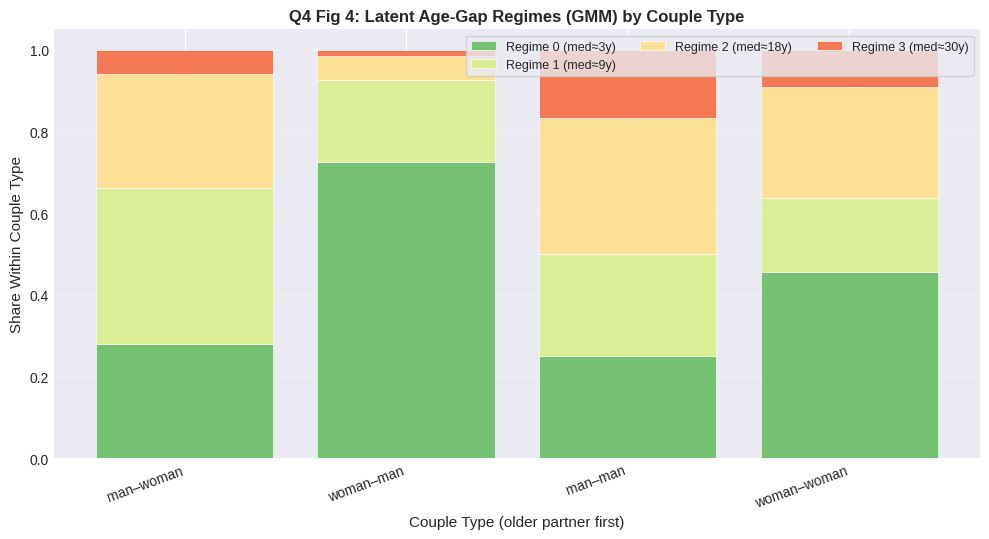

In [16]:
# --- FIG 4: GMM Regime Composition (Stacked Bar) ---
plt.figure(figsize=(10, 5.5))
bottom = np.zeros(len(MAIN_TYPES))
xpos = np.arange(len(MAIN_TYPES))

regime_colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, best_k))

for r in range(best_k):
    heights = regime_by_type_pct.loc[r, MAIN_TYPES].values
    plt.bar(xpos, heights, bottom=bottom, alpha=0.9,
            label=f"Regime {r} (med≈{regime_summary.loc[r, 'median_gap']:.0f}y)",
            color=regime_colors[r], edgecolor="white", linewidth=0.5)
    bottom += heights

plt.xticks(xpos, MAIN_TYPES, rotation=20, ha="right")
plt.ylabel("Share Within Couple Type", fontsize=11)
plt.xlabel("Couple Type (older partner first)", fontsize=11)
plt.title("Q4 Fig 4: Latent Age-Gap Regimes (GMM) by Couple Type", fontsize=12, weight="bold")
plt.legend(frameon=True, fontsize=9, ncol=min(best_k, 3), loc="upper right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/figures/Q4_Fig4_GMM_Regimes.png", dpi=300, bbox_inches="tight")
plt.show()

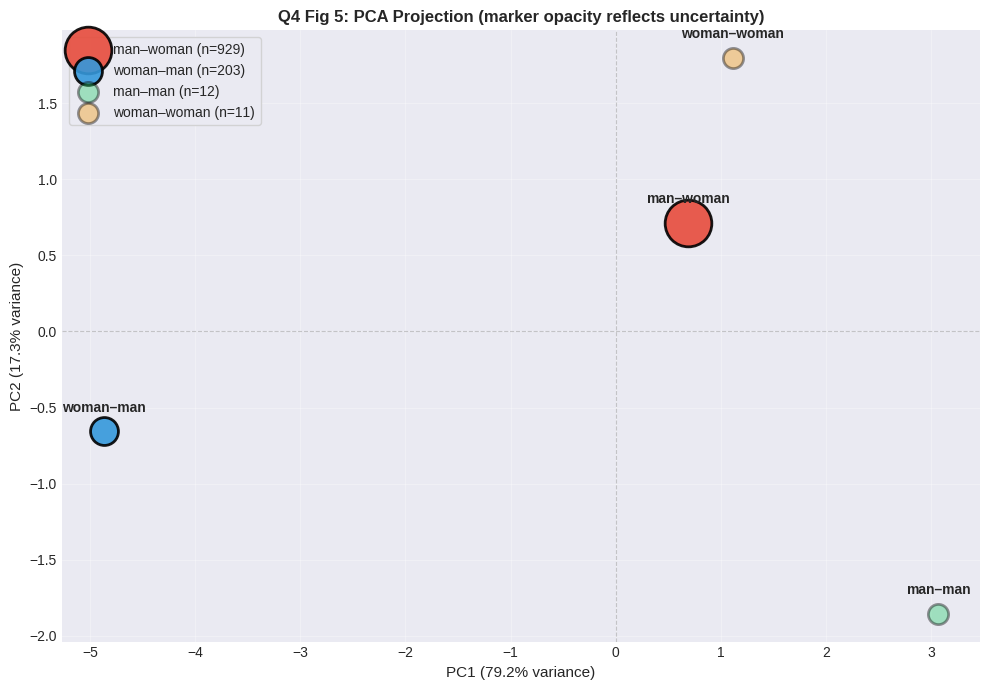

In [17]:
# --- FIG 5: PCA Biplot with Uncertainty Indicators ---
plt.figure(figsize=(10, 7))
for i, (_, row) in enumerate(df_couple_feat.iterrows()):
    # Get CI width from bootstrap results
    ci_width = boot_df[
        (boot_df["pairing_type"] == row["pairing_type"]) &
        (boot_df["parity_cutoff"] == 3)
    ]["median_ci_width"].values[0]

    # Size proportional to sample size, alpha inversely proportional to CI width
    marker_size = 200 + row["n"]
    marker_alpha = max(0.4, 1 - (ci_width / 10))  # More uncertain = more transparent

    plt.scatter(
        row["pc1"], row["pc2"],
        s=marker_size,
        color=colors[i],
        alpha=marker_alpha,
        edgecolors="black",
        linewidths=2,
        label=f"{row['pairing_type']} (n={row['n']:.0f})"
    )

    plt.annotate(
        row["pairing_type"],
        (row["pc1"], row["pc2"]),
        fontsize=10,
        weight="bold",
        ha="center",
        va="bottom",
        xytext=(0, 12),
        textcoords="offset points"
    )

plt.axhline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.4)
plt.axvline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.4)
plt.xlabel(f"PC1 ({explained_var[0]*100:.1f}% variance)", fontsize=11)
plt.ylabel(f"PC2 ({explained_var[1]*100:.1f}% variance)", fontsize=11)
plt.title("Q4 Fig 5: PCA Projection (marker opacity reflects uncertainty)", fontsize=12, weight="bold")
plt.legend(loc="best", frameon=True, fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/figures/Q4_Fig5_PCA_Biplot.png", dpi=300, bbox_inches="tight")
plt.show()

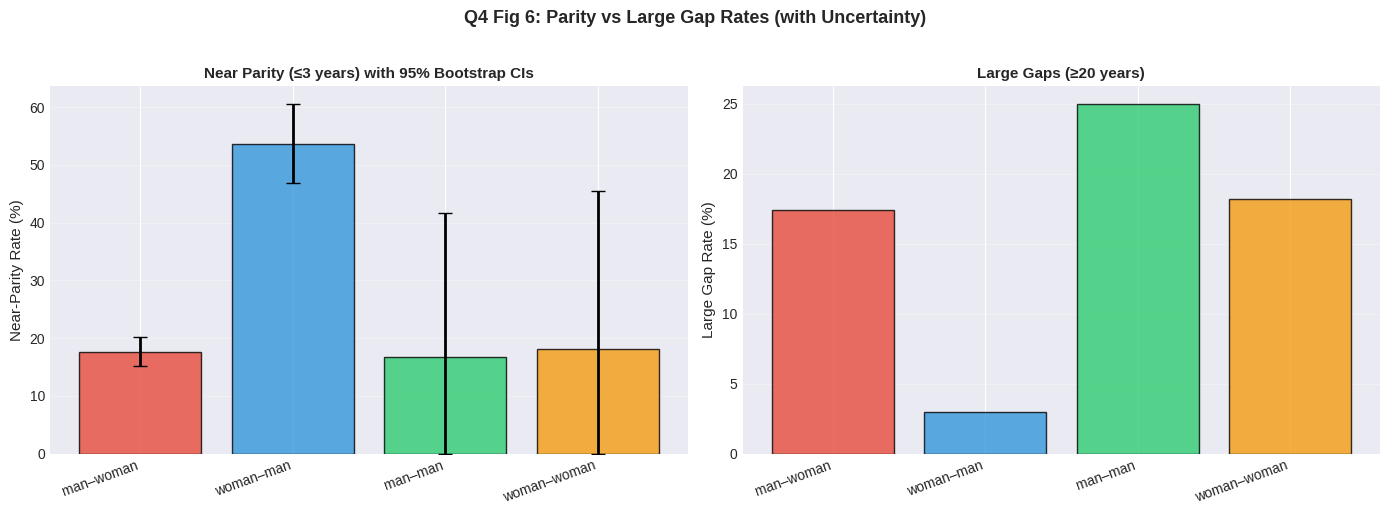

In [18]:
# --- FIG 6: Parity/Large Gap Comparison with Error Bars ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Parity rates with bootstrap CIs
parity_data = boot_df[boot_df["parity_cutoff"] == 3]
parity_rates = parity_data.set_index("pairing_type").reindex(MAIN_TYPES)["near_parity_rate"].values * 100
parity_errs_low = parity_data.set_index("pairing_type").reindex(MAIN_TYPES)["near_parity_ci_low"].values * 100
parity_errs_high = parity_data.set_index("pairing_type").reindex(MAIN_TYPES)["near_parity_ci_high"].values * 100

axes[0].bar(range(len(MAIN_TYPES)), parity_rates, color=colors, alpha=0.8, edgecolor="black")
axes[0].errorbar(range(len(MAIN_TYPES)), parity_rates,
                 yerr=[parity_rates - parity_errs_low, parity_errs_high - parity_rates],
                 fmt="none", ecolor="black", elinewidth=2, capsize=5)
axes[0].set_xticks(range(len(MAIN_TYPES)))
axes[0].set_xticklabels(MAIN_TYPES, rotation=20, ha="right")
axes[0].set_ylabel("Near-Parity Rate (%)", fontsize=11)
axes[0].set_title("Near Parity (≤3 years) with 95% Bootstrap CIs", fontsize=11, weight="bold")
axes[0].grid(axis="y", alpha=0.3)

# Large gap rates
large_gap_data = baseline_tables[3].reindex(MAIN_TYPES)["p_large_gap"].values * 100
axes[1].bar(range(len(MAIN_TYPES)), large_gap_data, color=colors, alpha=0.8, edgecolor="black")
axes[1].set_xticks(range(len(MAIN_TYPES)))
axes[1].set_xticklabels(MAIN_TYPES, rotation=20, ha="right")
axes[1].set_ylabel("Large Gap Rate (%)", fontsize=11)
axes[1].set_title("Large Gaps (≥20 years)", fontsize=11, weight="bold")
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("Q4 Fig 6: Parity vs Large Gap Rates (with Uncertainty)", fontsize=13, weight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/figures/Q4_Fig6_Parity_LargeGap.png", dpi=300, bbox_inches="tight")
plt.show()

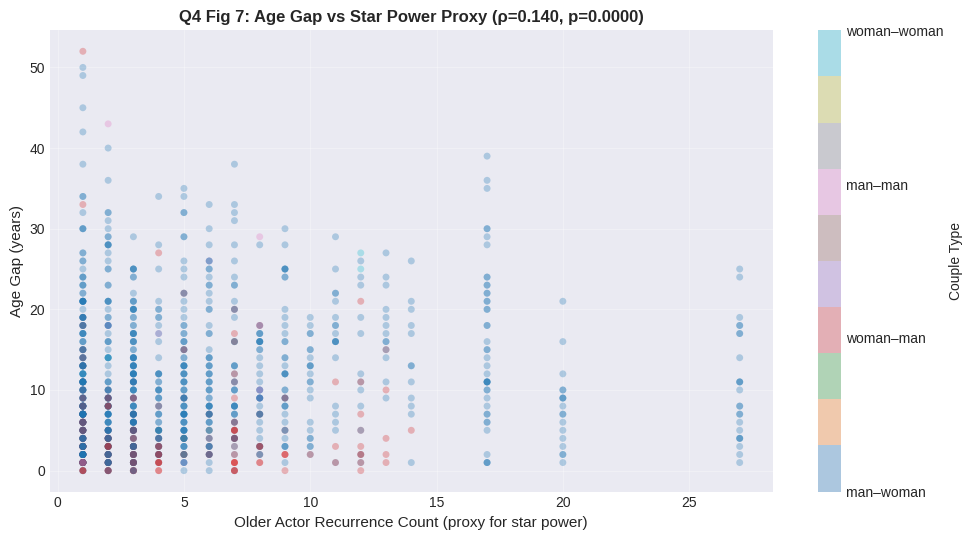

In [22]:
# --- FIG 7: Star Power Proxy Analysis ---
plt.figure(figsize=(10, 5.5))
plt.scatter(df["older_actor_freq"], df["age_gap"], s=25, alpha=0.3,
            c=df["pairing_type"].map({t: i for i, t in enumerate(MAIN_TYPES)}),
            cmap="tab10", edgecolors="none")
plt.xlabel("Older Actor Recurrence Count (proxy for star power)", fontsize=11)
plt.ylabel("Age Gap (years)", fontsize=11)
plt.title(f"Q4 Fig 7: Age Gap vs Star Power Proxy (ρ={rho_overall:.3f}, p={p_overall:.4f})",
          fontsize=12, weight="bold")
plt.colorbar(label="Couple Type", ticks=range(len(MAIN_TYPES)),
             format=plt.FuncFormatter(lambda x, p: MAIN_TYPES[int(x)] if int(x) < len(MAIN_TYPES) else ""))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/figures/Q4_Fig7_StarPower_Proxy.png", dpi=300, bbox_inches="tight")
plt.show()



In [21]:
# ============================================================================
# SECTION 10: KEY FINDINGS SUMMARY
# ============================================================================

print("\n" + "="*80)
print("KEY FINDINGS SUMMARY")
print("="*80)

print("\n[1] SEVERE SAMPLE IMBALANCE:")
print(f"    man-woman: n={type_counts['man–woman']} (80.4%)")
print(f"    woman-man: n={type_counts['woman–man']} (17.6%)")
print(f"    man-man: n={type_counts['man–man']} (1.0%)")
print(f"    woman-woman: n={type_counts['woman–woman']} (1.0%)")
print("    → Same-gender conclusions have wide uncertainty")

print("\n[2] GENDER-DIRECTIONAL EFFECT (MIXED-GENDER):")
print(f"    man-woman median: {baseline_tables[3].loc['man–woman', 'median_gap']:.1f}y")
print(f"    woman-man median: {baseline_tables[3].loc['woman–man', 'median_gap']:.1f}y")
print(f"    Permutation test p-value: {perm_df.iloc[0]['perm_pvalue']:.6f} (HIGHLY SIGNIFICANT)")

print("\n[3] GMM REGIME DISCOVERY:")
print(f"    Optimal components: k={best_k}")
print(f"    woman-man couples concentrate in near-parity regimes")
print(f"    man-woman couples spread into higher-gap regimes")

print("\n[4] PCA STRUCTURAL INSIGHT:")
print(f"    {explained_var.sum()*100:.1f}% variance captured in 2D")
print(f"    PC1 separates woman-man from all others")
print(f"    Consistent with 'older partner gender' being key variable")

print("\n[5] STAR POWER PROXY:")
print(f"    Spearman ρ = {rho_overall:.3f}, p = {p_overall:.4f}")
print(f"    Modest positive correlation supports economics mechanism")




KEY FINDINGS SUMMARY

[1] SEVERE SAMPLE IMBALANCE:
    man-woman: n=929 (80.4%)
    woman-man: n=203 (17.6%)
    man-man: n=12 (1.0%)
    woman-woman: n=11 (1.0%)
    → Same-gender conclusions have wide uncertainty

[2] GENDER-DIRECTIONAL EFFECT (MIXED-GENDER):
    man-woman median: 10.0y
    woman-man median: 3.0y
    Permutation test p-value: 0.000100 (HIGHLY SIGNIFICANT)

[3] GMM REGIME DISCOVERY:
    Optimal components: k=4
    woman-man couples concentrate in near-parity regimes
    man-woman couples spread into higher-gap regimes

[4] PCA STRUCTURAL INSIGHT:
    96.5% variance captured in 2D
    PC1 separates woman-man from all others
    Consistent with 'older partner gender' being key variable

[5] STAR POWER PROXY:
    Spearman ρ = 0.140, p = 0.0000
    Modest positive correlation supports economics mechanism
